# Project : Car Insurance Claim Prediction
## Author : Yazan Maghary 
## Date : 05/16/2026 mm/dd/yyyy
## Data_Dictionary : [Data_Dict](https://www.kaggle.com/datasets/sagnik1511/car-insurance-data)
> Table of Contents : 
1. [About Dataset](#About-Dataset)
2. [Importing Libraries](#Importing-Libraries)
3. [Load The Data Set](#Load-The-Data-Set)
4. [Check And Display The Data](#Check-And-Display-The-Data)
5. [Data Cleaning](#Data-Cleaning)
6. [Exploratory Data Analysis](#Exploratory-Data-Analysis)
7. [Preprocessing](#Preprocessing)
8. [Modeling And Evaluation](#Modeling-And-Evaluation)
9. [Feature Insights](#Feature-Insights)

# About Dataset
>  Context

The company has shared its annual car insurance data. Now, you have to find out the real customer behaviors over the data.

>  Content

The columns are resembling practical world features.
The outcome column indicates 1 if a customer has claimed his/her loan else 0.
The data has 19 features from there 18 of them are corresponding logs which were taken by the company.

>  Acknowledgements

Mostly the data is real and some part of it is also generated by me.

>  Inspiration

The data is so well balanced that it will help kagglers find a better intuition of real customers and find the deepest story lien within it.

# Importing Libraries

In [41]:

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import set_config
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split ,RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder , StandardScaler , OrdinalEncoder
import sys
from sklearn.pipeline import make_pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline as make_pipeline_imb
from sklearn.compose import ColumnTransformer 
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
sys.path.append('../src') 
from sklearn.inspection import permutation_importance
from class_eva_fun import *
from eda_utils import explore_numeric , plot_categorical_vs_target , explore_categorical
from ins_stakeholder import *

# Load The Data Set

In [68]:
path = '../Data/Car_Insurance_Claim.csv'
df =pd.read_csv(path)
pd.set_option('display.max_columns', None)
set_config(transform_output='pandas')

# Check And Display The Data

In [69]:
display(df.head(3) , df.info())
target = 'OUTCOME'

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   10000 non-null  int64  
 1   AGE                  10000 non-null  str    
 2   GENDER               10000 non-null  str    
 3   RACE                 10000 non-null  str    
 4   DRIVING_EXPERIENCE   10000 non-null  str    
 5   EDUCATION            10000 non-null  str    
 6   INCOME               10000 non-null  str    
 7   CREDIT_SCORE         9018 non-null   float64
 8   VEHICLE_OWNERSHIP    10000 non-null  float64
 9   VEHICLE_YEAR         10000 non-null  str    
 10  MARRIED              10000 non-null  float64
 11  CHILDREN             10000 non-null  float64
 12  POSTAL_CODE          10000 non-null  int64  
 13  ANNUAL_MILEAGE       9043 non-null   float64
 14  VEHICLE_TYPE         10000 non-null  str    
 15  SPEEDING_VIOLATIONS  10000 non-null  int64  
 16

,ID,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,569520,65+,female,majority,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,16-25,male,majority,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,16-25,female,majority,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0


None

# Data Cleaning

### Check for duplicated values : 
* There is no duplicated values in our data set 

In [4]:
df.duplicated().sum()

np.int64(0)

### Check For Null Values :
* CREDIT_SCORE > 982 nulls

* ANNUAL_MILEAGE > 957 nulls

* Both are floats so we don't need to fill them with constant values 

* we will impute them later in the preprocessing step to prevent data leakage


In [5]:
null_vals = df.isna()
null_vals.sum()[null_vals.sum() > 0]

CREDIT_SCORE      982
ANNUAL_MILEAGE    957
dtype: int64

In [6]:
null_pct = (df.isna().sum() / len(df) * 100).round(2)
print(null_pct[null_pct > 0])
# CREDIT_SCORE  → كم %؟
# ANNUAL_MILEAGE → كم %؟

CREDIT_SCORE      9.82
ANNUAL_MILEAGE    9.57
dtype: float64


### Check for nuniqe values

In [7]:
df.nunique()

ID                     10000
AGE                        4
GENDER                     2
RACE                       2
DRIVING_EXPERIENCE         4
EDUCATION                  3
INCOME                     4
CREDIT_SCORE            9018
VEHICLE_OWNERSHIP          2
VEHICLE_YEAR               2
MARRIED                    2
CHILDREN                   2
POSTAL_CODE                4
ANNUAL_MILEAGE            21
VEHICLE_TYPE               2
SPEEDING_VIOLATIONS       21
DUIS                       7
PAST_ACCIDENTS            15
OUTCOME                    2
dtype: int64

> set id as index

In [8]:
df = df.set_index('ID')
df.nunique()

AGE                       4
GENDER                    2
RACE                      2
DRIVING_EXPERIENCE        4
EDUCATION                 3
INCOME                    4
CREDIT_SCORE           9018
VEHICLE_OWNERSHIP         2
VEHICLE_YEAR              2
MARRIED                   2
CHILDREN                  2
POSTAL_CODE               4
ANNUAL_MILEAGE           21
VEHICLE_TYPE              2
SPEEDING_VIOLATIONS      21
DUIS                      7
PAST_ACCIDENTS           15
OUTCOME                   2
dtype: int64

### Check For Inconsistent Values and data types :
* value counts for categorical features
* Description for categorical features to check for high cardinality
* desc for numerical features to check for outliers or impossible values


In [9]:
cols = df.select_dtypes(include=['object']).columns
for col in cols:
    print(f"Column: {col}")
    print("*"*100)
    print(df[col].value_counts(dropna=False))
    print("\n")
    print("*"*100)

Column: AGE
****************************************************************************************************
AGE
26-39    3063
40-64    2931
16-25    2016
65+      1990
Name: count, dtype: int64


****************************************************************************************************
Column: GENDER
****************************************************************************************************
GENDER
female    5010
male      4990
Name: count, dtype: int64


****************************************************************************************************
Column: RACE
****************************************************************************************************
RACE
majority    9012
minority     988
Name: count, dtype: int64


****************************************************************************************************
Column: DRIVING_EXPERIENCE
****************************************************************************************************
DRIVIN

C:\Users\zezo2\AppData\Local\Temp\ipykernel_21444\1321133956.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols = df.select_dtypes(include=['object']).columns


In [10]:
df[cols].describe()

,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,VEHICLE_YEAR,VEHICLE_TYPE
count,10000,10000,10000,10000,10000,10000,10000,10000
unique,4,2,2,4,3,4,2,2
top,26-39,female,majority,0-9y,high school,upper class,before 2015,sedan
freq,3063,5010,9012,3530,4157,4336,6967,9523


> For categorical features there is no high cardinality, or Inconsistent Values

> For Numerical

In [11]:
df.describe()

,CREDIT_SCORE,VEHICLE_OWNERSHIP,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
count,9018.000000,10000.000000,10000.000000,10000.000000,10000.000000,9043.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,0.515813,0.697000,0.498200,0.688800,19864.548400,11697.003207,1.482900,0.23920,1.056300,0.313300
std,0.137688,0.459578,0.500022,0.463008,18915.613855,2818.434528,2.241966,0.55499,1.652454,0.463858
min,0.053358,0.000000,0.000000,0.000000,10238.000000,2000.000000,0.000000,0.00000,0.000000,0.000000
25%,0.417191,0.000000,0.000000,0.000000,10238.000000,10000.000000,0.000000,0.00000,0.000000,0.000000
50%,0.525033,1.000000,0.000000,1.000000,10238.000000,12000.000000,0.000000,0.00000,0.000000,0.000000
75%,0.618312,1.000000,1.000000,1.000000,32765.000000,14000.000000,2.000000,0.00000,2.000000,1.000000
max,0.960819,1.000000,1.000000,1.000000,92101.000000,22000.000000,22.000000,6.00000,15.000000,1.000000


> Depending on the box plot :
* there is outliers so we will impute with median later

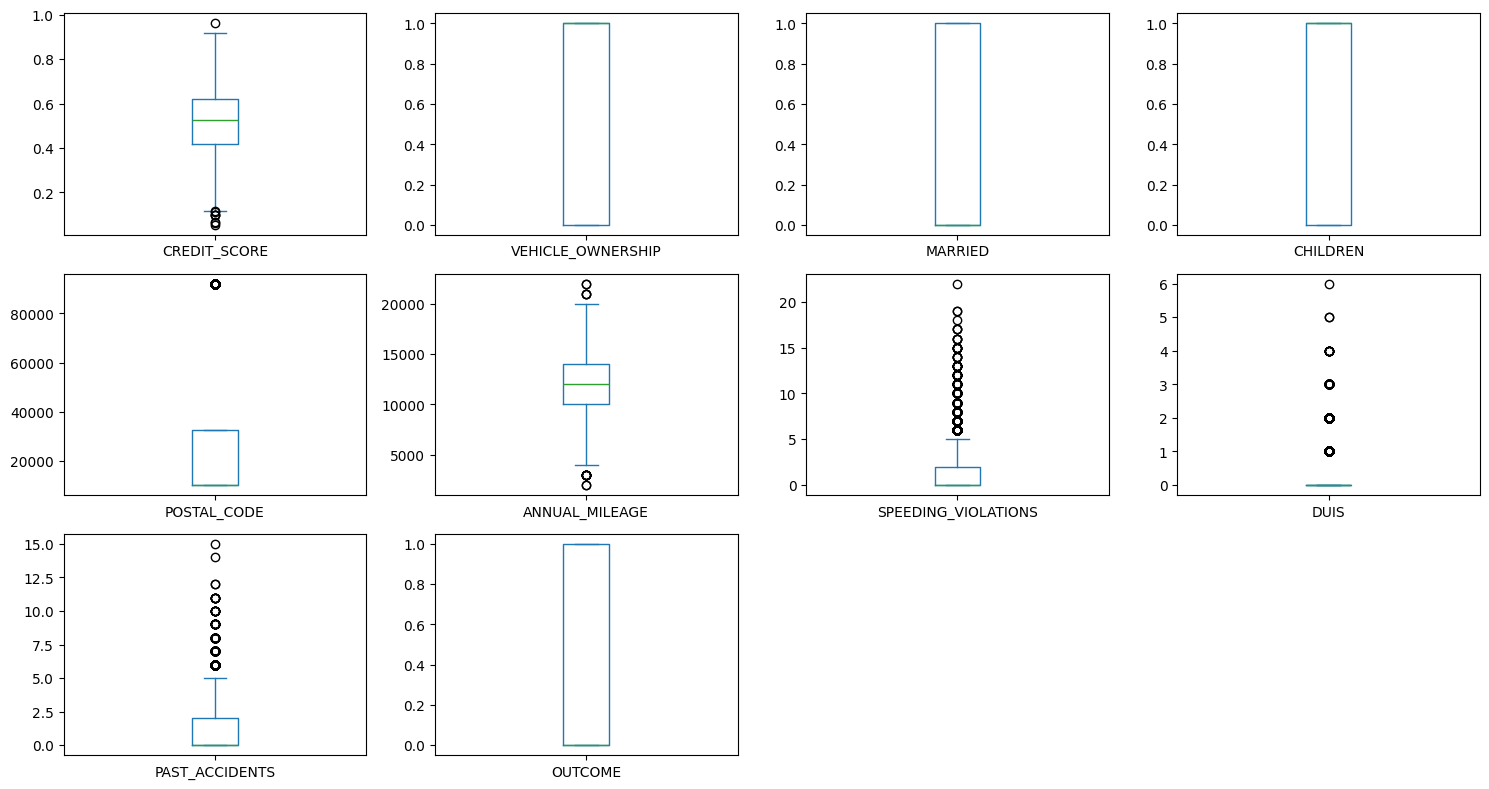

In [12]:
num_cols = df.select_dtypes('number').columns
df[num_cols].plot(kind='box', subplots=True, 
                  figsize=(15,8), layout=(3,4))
plt.tight_layout()
plt.show()

# Exploratory Data Analysis
* our target will be 1 if a customer has claimed his/her loan else 0
* target type : classification 

> First Impute Numeric nulls with median 
* hint : make a copy of the original data frame to prevent data leakage

In [13]:
df_copy = df.copy()
replace_Outcome = {
    'claimed': 1,
    'unclaimed': 0
}
df_copy['OUTCOME'] = df_copy['OUTCOME'].replace(replace_Outcome)
df_copy['OUTCOME'].value_counts()
# CREDIT_SCORE           ANNUAL_MILEAGE          filled with median
df_copy['CREDIT_SCORE'] =df_copy['CREDIT_SCORE'].fillna(df_copy['CREDIT_SCORE'].median())
df_copy['ANNUAL_MILEAGE'] =df_copy['ANNUAL_MILEAGE'].fillna(df_copy['ANNUAL_MILEAGE'].median(),)
df_copy.isna().sum()


AGE                    0
GENDER                 0
RACE                   0
DRIVING_EXPERIENCE     0
EDUCATION              0
INCOME                 0
CREDIT_SCORE           0
VEHICLE_OWNERSHIP      0
VEHICLE_YEAR           0
MARRIED                0
CHILDREN               0
POSTAL_CODE            0
ANNUAL_MILEAGE         0
VEHICLE_TYPE           0
SPEEDING_VIOLATIONS    0
DUIS                   0
PAST_ACCIDENTS         0
OUTCOME                0
dtype: int64

### Explore Numerical Features :
* We Well check for correlation between numerical features and choose most two correlated features with target
* Numerical Feature Exploration 
* Target vs Numerical Feature
* Insights 

> Check Correlation

<Axes: >

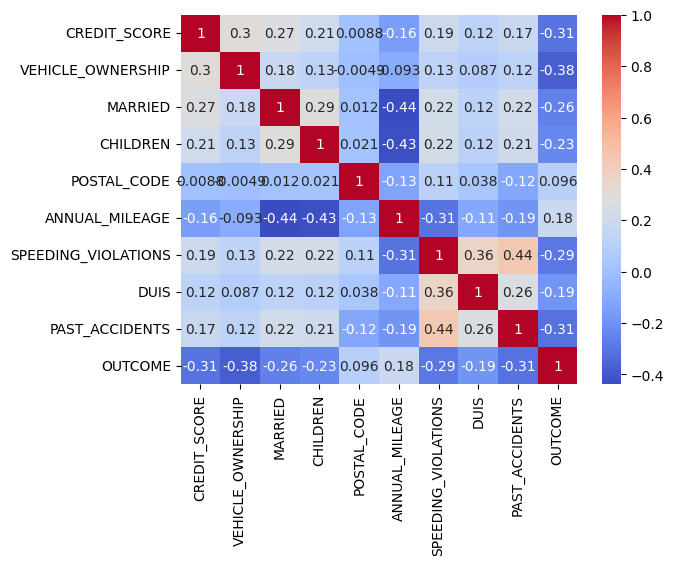

In [14]:
corr =df_copy.corr(numeric_only=True)
sns.heatmap(corr,annot=True, cmap='coolwarm')

**We will explore Credit Score and Speeding Violations**

#### Credit Score vs Target

> Credit Score Vis

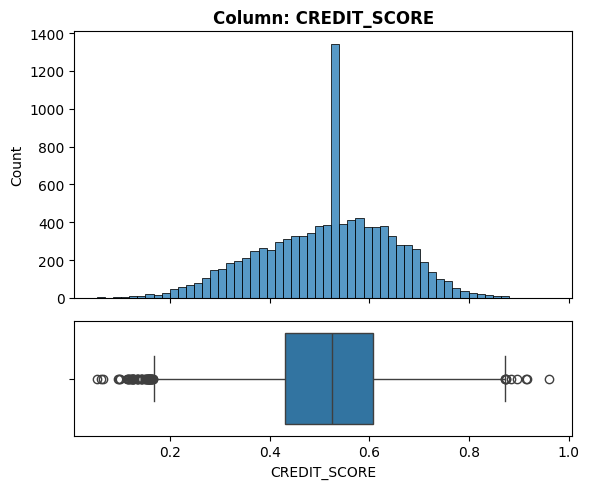

- NaN's Found: 0 (0.0%)
- Unique Values: 9019
- Most common value: '0.5250327586154788' occurs 982 times (9.82%)
- Not constant or quasi-constant.


(<Figure size 600x500 with 2 Axes>,
 array([<Axes: title={'center': 'Column: CREDIT_SCORE'}, xlabel='CREDIT_SCORE', ylabel='Count'>,
        <Axes: xlabel='CREDIT_SCORE'>], dtype=object))

In [15]:
feature = 'CREDIT_SCORE'
explore_numeric(df_copy, feature)

> We can Note :
* Feature : CREDIT_SCORE , type : numeric
* Null Values : 0 , percent : 0% 
* Would we know this BEFORE the target is determined?
  - ... Yes

* Is there a business case/understanding reason to exclude based on our business case?
  - ... No there is no business case to exclude this feature


> Credit Score vs Target Vis

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'CREDIT_SCORE vs. OUTCOME'}, xlabel='CREDIT_SCORE', ylabel='Percent'>)

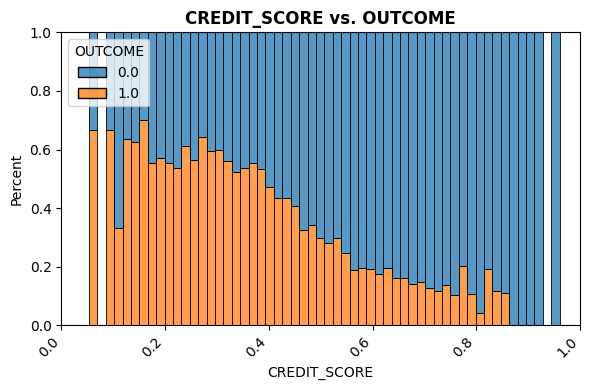

In [16]:
plot_categorical_vs_target(df_copy, 'CREDIT_SCORE', 'OUTCOME', figsize=(6,4) , target_type='class')

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - `...` Yes , it would be a predictor of the target
  - Does this feature appear to be a predictor of the target?
    - `...` Yes , we can note that lower Credit Scores are more likely to claim a loan

#### Credit Score vs Speeding Violations

> Speeding Violations Vis

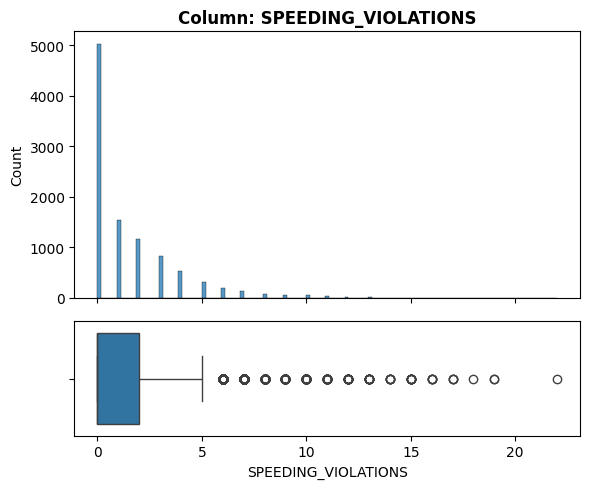

- NaN's Found: 0 (0.0%)
- Unique Values: 21
- Most common value: '0' occurs 5028 times (50.28%)
- Not constant or quasi-constant.


(<Figure size 600x500 with 2 Axes>,
 array([<Axes: title={'center': 'Column: SPEEDING_VIOLATIONS'}, xlabel='SPEEDING_VIOLATIONS', ylabel='Count'>,
        <Axes: xlabel='SPEEDING_VIOLATIONS'>], dtype=object))

In [17]:
feature = 'SPEEDING_VIOLATIONS'
explore_numeric(df_copy, feature)

> We can Note :
* Feature : SPEEDING_VIOLATIONS , type : numeric
* Null Values : 0 , percent : 0% 
* Would we know this BEFORE the target is determined?
  - ... Yes

* Is there a business case/understanding reason to exclude based on our business case?
  - ... No there is no business case to exclude this feature

> Speeding Violations vs Target Vis

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'SPEEDING_VIOLATIONS vs. OUTCOME'}, xlabel='SPEEDING_VIOLATIONS', ylabel='Percent'>)

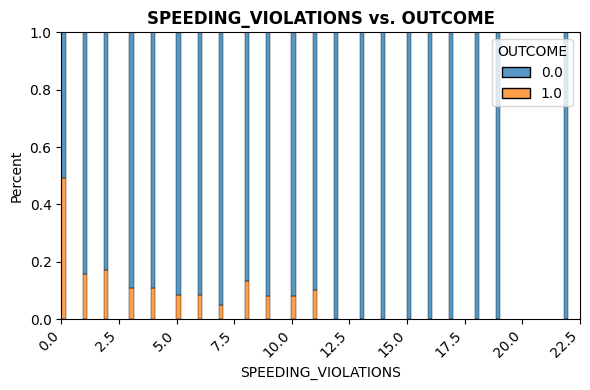

In [18]:
plot_categorical_vs_target(df_copy, feature, 'OUTCOME', figsize=(6,4) , target_type='class')


- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - `...` Yes
  - Does this feature appear to be a predictor of the target?
    - `...` Yes , but not a strong one , we can not that who claimed the loan have speeding violations less than 12 times

### Explore Categorical Features :
* Categorical Feature Exploration 
* Target vs Categorical Feature
* Insights 

> Choosing 2 features for exploration

In [19]:
df_copy.describe(include='object')

C:\Users\zezo2\AppData\Local\Temp\ipykernel_21444\1467874966.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_copy.describe(include='object')


,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,VEHICLE_YEAR,VEHICLE_TYPE
count,10000,10000,10000,10000,10000,10000,10000,10000
unique,4,2,2,4,3,4,2,2
top,26-39,female,majority,0-9y,high school,upper class,before 2015,sedan
freq,3063,5010,9012,3530,4157,4336,6967,9523


Choosing INCOME and DRIVING_EXPERIENCE

> INCOME 

d:\Computer Systems Engineering\Data Sciecne\AXSOSACADEMY\Project2\notebook\../src\eda_utils.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


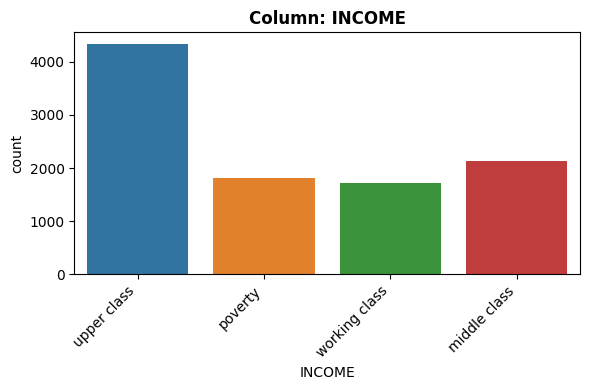

- NaN's Found: 0 (0.0%)
- Unique Values: 4
- Most common value: 'upper class' occurs 4336 times (43.36%)
- Not constant or quasi-constant.


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Column: INCOME'}, xlabel='INCOME', ylabel='count'>)

In [20]:
feature = 'INCOME'
explore_categorical(df_copy, feature)

> We can Note :
* Feature : Species , type : str
* Most common value : upper class , occurs 4336  times (43.36%)
* its not constant or quasi-constant.
* Unique values : 4 , its low cardinality
* Would we know this BEFORE the target is determined?
  - ... Yes

* Is there a business case/understanding reason to exclude based on our business case?
  - ... No there is no business case to exclude this feature


> INCOME vs Target Vis

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'INCOME vs. OUTCOME'}, xlabel='INCOME', ylabel='Percent'>)

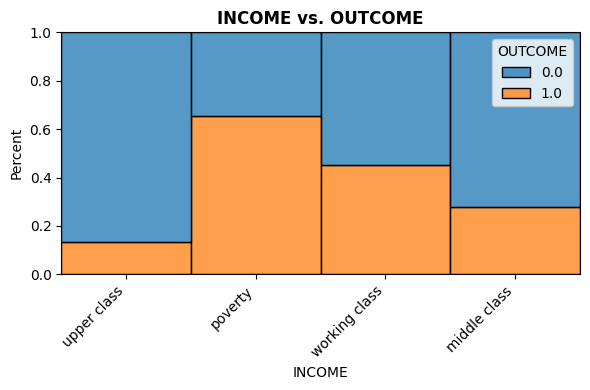

In [21]:
plot_categorical_vs_target(df_copy, feature, 'OUTCOME', figsize=(6,4) , target_type='class',)

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - `...` Yes
  - Does this feature appear to be a predictor of the target?
    - `...` Yes , and it will be strojg predictor , se we can note that poverty class and lower class are more likely to claim a loan than middle class and upper class

> DRIVING_EXPERIENCE

d:\Computer Systems Engineering\Data Sciecne\AXSOSACADEMY\Project2\notebook\../src\eda_utils.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


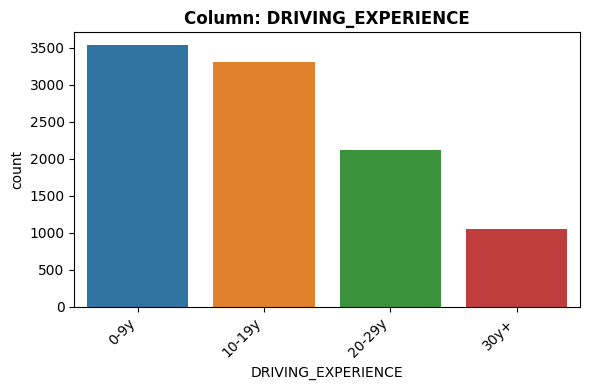

- NaN's Found: 0 (0.0%)
- Unique Values: 4
- Most common value: '0-9y' occurs 3530 times (35.3%)
- Not constant or quasi-constant.


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Column: DRIVING_EXPERIENCE'}, xlabel='DRIVING_EXPERIENCE', ylabel='count'>)

In [22]:
feature = 'DRIVING_EXPERIENCE'
explore_categorical(df_copy, feature)

> We can Note :
* Feature : DRIVING_EXPERIENCE , type : str
* Most common value : upper class , occurs 3530 times (35.3%)
* its not constant or quasi-constant.
* Unique values : 4 , its low cardinality
* Would we know this BEFORE the target is determined?
  - ... Yes

* Is there a business case/understanding reason to exclude based on our business case?
  - ... No there is no business case to exclude this feature


> DRIVING_EXPERIENCE vs Target Vis

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'DRIVING_EXPERIENCE vs. OUTCOME'}, xlabel='DRIVING_EXPERIENCE', ylabel='Percent'>)

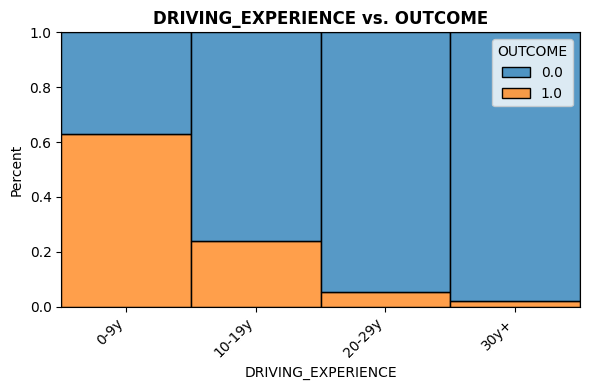

In [23]:
plot_categorical_vs_target(df_copy, feature, 'OUTCOME', figsize=(6,4) , target_type='class')

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - `...` Yes
  - Does this feature appear to be a predictor of the target?
    - `...` Yes , and it will be strojg predictor , se we can note that who have less driving experience are more likely to claim a loan

# Preprocessing

In [24]:
df.info()

<class 'pandas.DataFrame'>
Index: 10000 entries, 569520 to 442696
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   AGE                  10000 non-null  str    
 1   GENDER               10000 non-null  str    
 2   RACE                 10000 non-null  str    
 3   DRIVING_EXPERIENCE   10000 non-null  str    
 4   EDUCATION            10000 non-null  str    
 5   INCOME               10000 non-null  str    
 6   CREDIT_SCORE         9018 non-null   float64
 7   VEHICLE_OWNERSHIP    10000 non-null  float64
 8   VEHICLE_YEAR         10000 non-null  str    
 9   MARRIED              10000 non-null  float64
 10  CHILDREN             10000 non-null  float64
 11  POSTAL_CODE          10000 non-null  int64  
 12  ANNUAL_MILEAGE       9043 non-null   float64
 13  VEHICLE_TYPE         10000 non-null  str    
 14  SPEEDING_VIOLATIONS  10000 non-null  int64  
 15  DUIS                 10000 non-null  int64  
 

In [25]:
y = df[target]
X = df.drop(target, axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
display(X_train.head(3) , y_train.head(3))

,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS
ID,,,,,,,,,,,,,,,,,
340922,65+,female,majority,30y+,high school,upper class,0.545417,1.0,after 2015,1.0,1.0,10238,8000.0,sedan,4,0,6
602525,26-39,male,majority,0-9y,none,poverty,0.361876,0.0,before 2015,1.0,1.0,10238,9000.0,sedan,0,0,0
761223,26-39,female,minority,0-9y,university,middle class,0.535840,1.0,before 2015,1.0,0.0,10238,12000.0,sedan,0,0,0


ID
340922    0.0
602525    1.0
761223    0.0
Name: OUTCOME, dtype: float64

In [26]:
df[target].value_counts(normalize=True)

OUTCOME
0.0    0.6867
1.0    0.3133
Name: proportion, dtype: float64

In [27]:
smote = SMOTE(random_state=42)
cat_cols = X_train.select_dtypes('object').columns
ord_cols = ['AGE' ,'DRIVING_EXPERIENCE','EDUCATION','INCOME','VEHICLE_YEAR']
cat_cols = cat_cols.drop(ord_cols)
cat_cols

C:\Users\zezo2\AppData\Local\Temp\ipykernel_21444\839925540.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes('object').columns


Index(['GENDER', 'RACE', 'VEHICLE_TYPE'], dtype='str')

> Categorical

In [28]:
ohe = OneHotEncoder(handle_unknown='ignore' ,   sparse_output=False)
ohe_tuple = ('Categorical',ohe , cat_cols)
ohe_tuple

('Categorical',
 OneHotEncoder(handle_unknown='ignore', sparse_output=False),
 Index(['GENDER', 'RACE', 'VEHICLE_TYPE'], dtype='str'))

> Ordinal 

In [29]:
# ordinal encoder
age_order              = ['16-25', '26-39', '40-64', '65+']
driving_exp_order      = ['0-9y', '10-19y', '20-29y', '30y+']
education_order        = ['none', 'high school', 'university']
income_order           = ['poverty', 'working class', 'middle class', 'upper class']
vehicle_year_order     = ['before 2015', 'after 2015']
ord_encoder = OrdinalEncoder(categories=[age_order, driving_exp_order, education_order, income_order, vehicle_year_order] ,)
ord_pipe_scaler = make_pipeline(ord_encoder , StandardScaler())
ord_tuple_scaled = ('Ordinal', ord_pipe_scaler , ord_cols)
ord_tuple = ('Ordinal', ord_encoder , ord_cols)

> Numeric

In [30]:
num_cols = X_train.select_dtypes('number').columns
scaler = StandardScaler()
imputer = SimpleImputer(strategy='median')
num_pipe_scaled = make_pipeline(imputer , scaler)
num_tuple_scaled = ('Numeric', num_pipe_scaled , num_cols)
num_tuple = ('Numeric', imputer , num_cols)


> Tramnform and fit the data

In [31]:
columns_transformers_scaled = ColumnTransformer(transformers=[
    ohe_tuple,
    ord_tuple_scaled,
    num_tuple_scaled
])
columns_transformers = ColumnTransformer(transformers=[
    ohe_tuple,
    ord_tuple,
    num_tuple
])

# Modeling And Evaluation

> Using Default Random Forest Classifier

----------------------------------------------------------------------
Classification metrics : Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

   unclaimed       1.00      1.00      1.00      5500
     claimed       1.00      1.00      1.00      2500

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000



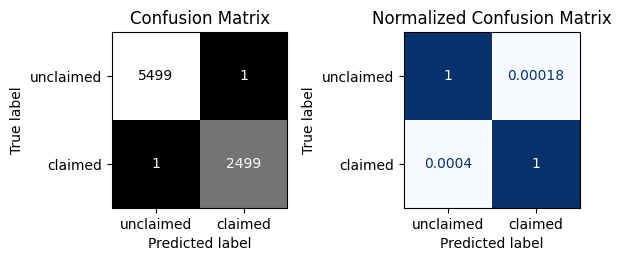


----------------------------------------------------------------------
Classification metrics : Testing Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

   unclaimed       0.86      0.90      0.88      1367
     claimed       0.76      0.68      0.72       633

    accuracy                           0.83      2000
   macro avg       0.81      0.79      0.80      2000
weighted avg       0.83      0.83      0.83      2000



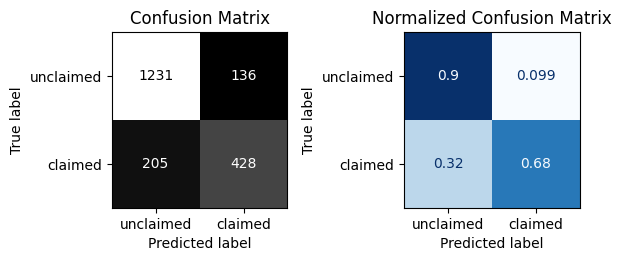

In [32]:
rf_clf = RandomForestClassifier(random_state=42)
rf_pipe = make_pipeline_imb(columns_transformers ,smote, rf_clf)
rf_pipe.fit(X_train , y_train)
evaluation_classification(rf_pipe , X_train , y_train , X_test , y_test , target_names=['unclaimed' , 'claimed'])

> With only Evaluation

In [33]:
params = {
    'randomforestclassifier__n_estimators'  : [100, 200, 300],
    'randomforestclassifier__max_depth'     : [3, 5, 10, 15 ,20],
    'randomforestclassifier__min_samples_split' : [2, 5, 10],
    'randomforestclassifier__max_features'  : ['sqrt', 'log2']
}

In [34]:
rf_clf = RandomForestClassifier(random_state=42)
rf_pipe = make_pipeline_imb(columns_transformers ,smote, rf_clf)
ran_search = RandomizedSearchCV(estimator=rf_pipe, param_distributions=params, n_iter=100, cv=5, n_jobs=-1,verbose=1,scoring='recall')


In [35]:
ran_search.fit(X_train, y_train)

C:\Users\zezo2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 90 is smaller than n_iter=100. Running 90 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 90 candidates, totalling 450 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'randomforestclassifier__max_depth': [3, 5, ...], 'randomforestclassifier__max_features': ['sqrt', 'log2'], 'randomforestclassifier__min_samples_split': [2, 5, ...], 'randomforestclassifier__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across call

----------------------------------------------------------------------
Classification metrics : Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

   unclaimed       0.90      0.82      0.86      5500
     claimed       0.67      0.81      0.73      2500

    accuracy                           0.82      8000
   macro avg       0.79      0.81      0.80      8000
weighted avg       0.83      0.82      0.82      8000



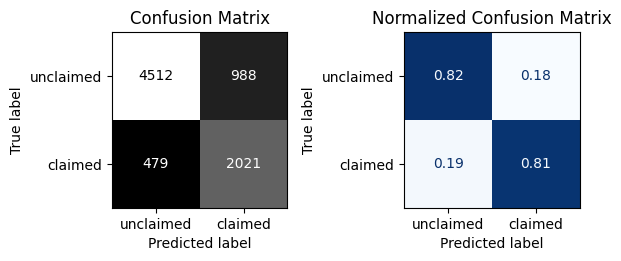


----------------------------------------------------------------------
Classification metrics : Testing Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

   unclaimed       0.89      0.82      0.85      1367
     claimed       0.67      0.78      0.72       633

    accuracy                           0.81      2000
   macro avg       0.78      0.80      0.79      2000
weighted avg       0.82      0.81      0.81      2000



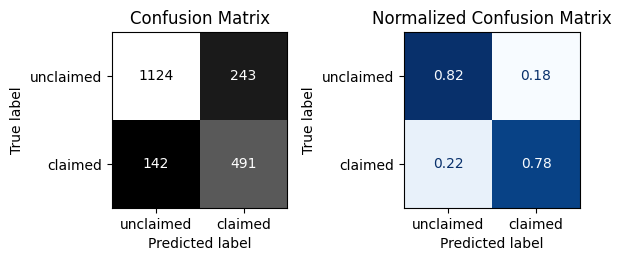

In [36]:
evaluation_classification(ran_search.best_estimator_ , X_train , y_train , X_test , y_test , target_names=['unclaimed' , 'claimed'])

## Model Evaluation — Training & Testing Data

### Focus Metric : Recall

In the context of car insurance, **Recall is our most important metric**.

A **False Negative** (predicting a customer won't claim but they do) is far 
more costly to the company than a **False Positive**.

Missing a real claim means the company is **financially unprepared** — which 
is the worst outcome for an insurance business.

---

### Training Results

| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| Unclaimed | 0.90 | 0.82 | 0.86 | 5500 |
| Claimed | 0.67 | 0.81 | 0.73 | 2500 |
| **Accuracy** | | | **0.82** | 8000 |

---

### Testing Results

| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| Unclaimed | 0.89 | 0.82 | 0.85 | 1367 |
| Claimed | 0.67 | 0.78 | 0.72 | 633 |
| **Accuracy** | | | **0.81** | 2000 |

---

### Interpretation

**Overfitting Check ✅**
- Train Accuracy : 0.82 — Test Accuracy : 0.81
- Difference of only 1% — the model generalizes well with no signs of overfitting

**Recall — claimed class**
- Train : 0.81 — Test : 0.78
- The model correctly identifies ~78-81% of customers who will file a claim ✅
- Small drop from train to test is normal and acceptable

**Precision — claimed class**
- Both train and test = 0.67
- When the model predicts a claim, it is correct 67% of the time
- Lower precision is acceptable here since **missing a claim (low recall)**
  is more costly than a false alarm (low precision)

**Unclaimed class**
- Strong performance on both train and test (Recall 0.82)
- Expected since unclaimed is the majority class

---

### Overall Conclusion

> The model shows **consistent and stable performance** between training 
> and testing data. With a **Recall of 0.78** on the claimed class, 
> the model is well-suited for identifying high-risk customers, 
> which is the primary goal of a car insurance prediction model. 🎯

> So we want to increase recall using threshold tuning.

C:\Users\zezo2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\zezo2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\zezo2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:18

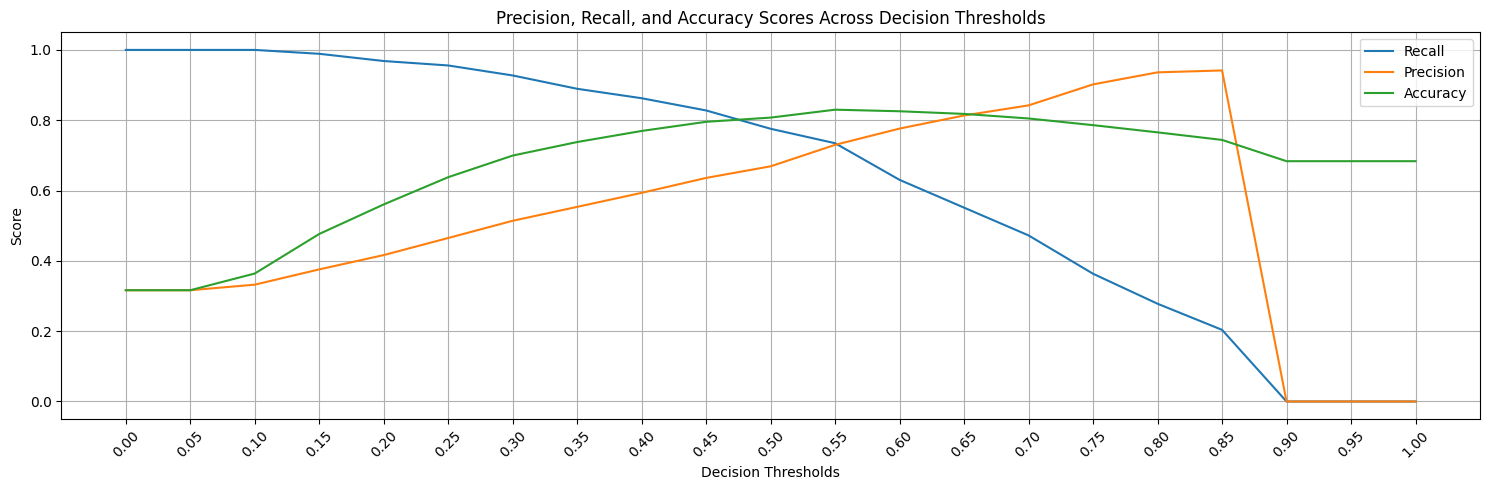

,Threshold,Recall,Precision,Accuracy
0,0.00,1.000,0.316,0.316
1,0.05,1.000,0.316,0.316
2,0.10,1.000,0.332,0.364
3,0.15,0.989,0.376,0.476
4,0.20,0.968,0.416,0.560
5,0.25,0.956,0.465,0.638
6,0.30,0.927,0.514,0.700
7,0.35,0.889,0.554,0.738
8,0.40,0.863,0.593,0.770
9,0.45,0.828,0.636,0.796


In [37]:

plot_threshold_metrics(ran_search.best_estimator_ , X_test , y_test ,)

  Threshold = 0.3

----------------------------------------------------------------------
Classification metrics : Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

   unclaimed       0.95      0.60      0.74      5500
     claimed       0.52      0.93      0.66      2500

    accuracy                           0.71      8000
   macro avg       0.73      0.77      0.70      8000
weighted avg       0.82      0.71      0.71      8000



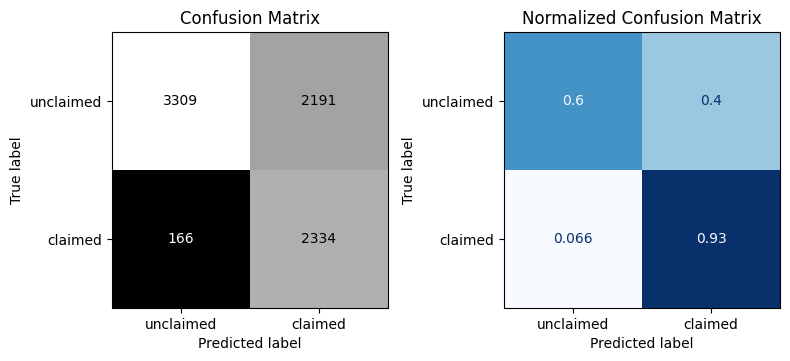


----------------------------------------------------------------------
Classification metrics : Testing Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

   unclaimed       0.95      0.59      0.73      1367
     claimed       0.51      0.93      0.66       633

    accuracy                           0.70      2000
   macro avg       0.73      0.76      0.70      2000
weighted avg       0.81      0.70      0.71      2000



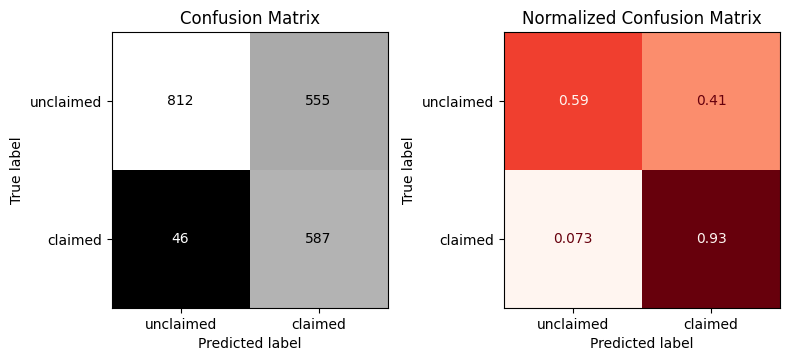

In [38]:
evaluate_with_threshold(ran_search.best_estimator_ , X_train , y_train , X_test , y_test,target_names=['unclaimed' , 'claimed'])

> we increased recall score from 78 ro 93 that very good for predicting claims.

## Threshold Tuning Results

By lowering the decision threshold, we prioritized **Recall over Precision**
since missing a real insurance claim is more costly than a false alarm.

### Key Improvements
- Claimed Recall : 0.78 → **0.93** ✅ catches 93% of real claims
- Trade-off      : Precision dropped from 0.67 → 0.51 (acceptable)
- No Overfitting : Train/Test results differ by less than 1%

### Final Decision
The tuned threshold model is preferred for deployment in an insurance
context where **catching real claims is the top priority.** 🎯

# Feature Insights

> Top 10 Feature using permutation importance 

In [48]:
features_name = ran_search.best_estimator_.named_steps['columntransformer'].get_feature_names_out()
r = permutation_importance(estimator=ran_search.best_estimator_, X=X_test, y=y_test, n_repeats=10, random_state=42)
r.keys()

dict_keys(['importances_mean', 'importances_std', 'importances'])

In [55]:
permut_impor = pd.Series(r['importances_mean'] , index=X_train.columns  , name='Permutation Importance')
permut_impor.sort_values(ascending=False)

DRIVING_EXPERIENCE     0.02885
VEHICLE_YEAR           0.02385
VEHICLE_OWNERSHIP      0.02135
GENDER                 0.00035
VEHICLE_TYPE           0.00000
RACE                  -0.00020
EDUCATION             -0.00025
POSTAL_CODE           -0.00025
ANNUAL_MILEAGE        -0.00055
CREDIT_SCORE          -0.00150
CHILDREN              -0.00250
DUIS                  -0.00275
MARRIED               -0.00610
INCOME                -0.00700
AGE                   -0.00725
PAST_ACCIDENTS        -0.00885
SPEEDING_VIOLATIONS   -0.01115
Name: Permutation Importance, dtype: float64

<Axes: title={'center': 'Top 10 Most Important Features'}, xlabel='Importance', ylabel='Feature Names'>

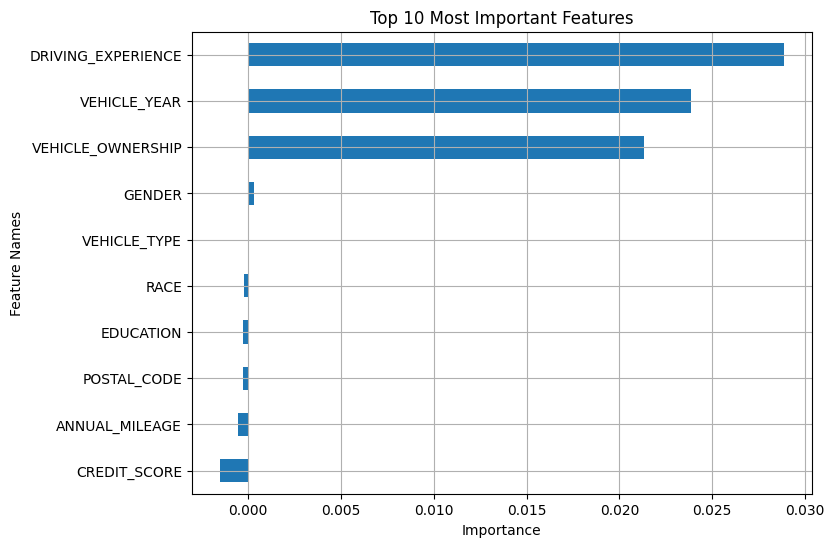

In [58]:
plot_importance(permut_impor,top_n=10)

## Permutation Importance — Business Observations

### Top 3 Most Important Features

| Feature | Importance | Business Sense |
|---------|------------|----------------|
| DRIVING_EXPERIENCE | ~0.029 | ✅ Makes perfect sense |
| VEHICLE_YEAR | ~0.024 | ✅ Makes perfect sense |
| VEHICLE_OWNERSHIP | ~0.021 | ✅ Makes perfect sense |

---

### Feature by Feature Analysis

**1 — DRIVING_EXPERIENCE (Most Important ~0.029)**
The most influential feature — highly logical from a business perspective.
Drivers with less experience (0-9y) are statistically more likely to cause
accidents and file claims compared to experienced drivers (30y+).
Insurance companies worldwide use driving experience as a primary pricing factor.

**2 — VEHICLE_YEAR (~0.024)**
Newer vehicles (after 2015) tend to have better safety features (ABS, airbags,
lane assist) which reduces accident likelihood. Older vehicles may lack these
features and are more

### Visualization of the most 2 important features : 

**1 — DRIVING_EXPERIENCE (Most Important ~0.029)**
The most influential feature — highly logical from a business perspective.
Drivers with less experience (0-9y) are statistically more likely to cause
accidents and file claims compared to experienced drivers (30y+).
Insurance companies worldwide use driving experience as a primary pricing factor.

**2 — VEHICLE_YEAR (~0.024)**
Newer vehicles (after 2015) tend to have better safety features (ABS, airbags,
lane assist) which reduces accident likelihood. Older vehicles may lack these
features and are more

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'DRIVING_EXPERIENCE vs. OUTCOME'}, xlabel='DRIVING_EXPERIENCE', ylabel='Percent'>)

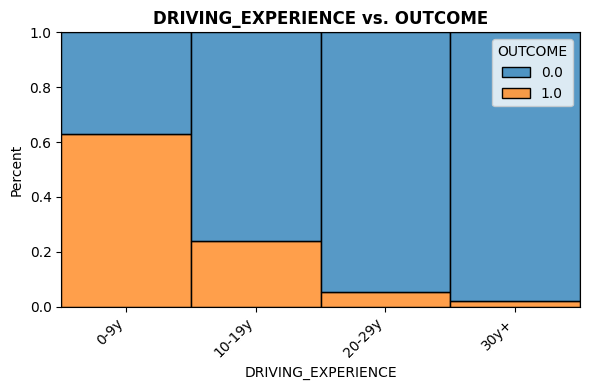

In [ ]:
# 1 — DRIVING_EXPERIENCE vs OUTCOME
feature ='DRIVING_EXPERIENCE'

plot_categorical_vs_target(df , x=feature ,y=target,target_type='class')

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'VEHICLE_YEAR vs. OUTCOME'}, xlabel='VEHICLE_YEAR', ylabel='Percent'>)

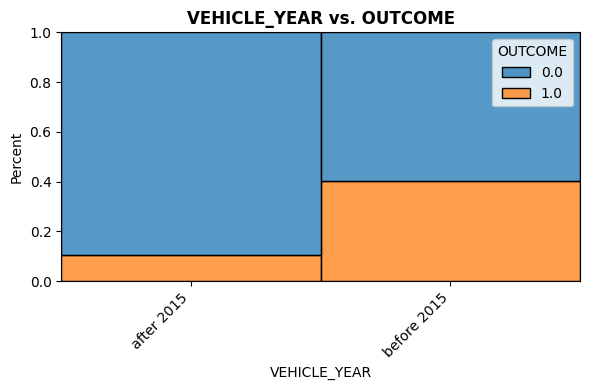

In [66]:
# 1 — VEHICLE_YEAR  vs OUTCOME
feature ='VEHICLE_YEAR'

plot_categorical_vs_target(df , x=feature ,y=target,target_type='class')